In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [2]:
# Gizli Sayıyı
secret_number = '1000101'
n = len(secret_number) # Kübit sayısı (7)

In [3]:
# (n giriş kübiti + 1 hedef kübiti)
circuit = QuantumCircuit(n + 1, n)

In [4]:
# Giriş kübitlerine (0'dan 6'ya) Hadamard 
circuit.h(range(n))

In [5]:
# Hedef kübiti (7.) önce |1> yap, sonra Hadamard uygula ( |- state )
circuit.x(n)
circuit.h(n)

circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=8, num_clbits=0, params=[]), qubits=(<Qubit register=(8, "q"), index=0>, <Qubit register=(8, "q"), index=1>, <Qubit register=(8, "q"), index=2>, <Qubit register=(8, "q"), index=3>, <Qubit register=(8, "q"), index=4>, <Qubit register=(8, "q"), index=5>, <Qubit register=(8, "q"), index=6>, <Qubit register=(8, "q"), index=7>), clbits=())

In [6]:
# ORACLE (Gizli Sayıyı Kodlama)
# Gizli sayıdaki '1' olan yerlere CNOT kapısı koyuyoruz.
# Qiskit sayıları sağdan sola okur (Little Endian).
for index, bit in enumerate(reversed(secret_number)):
    if bit == '1':
        circuit.cx(index, n)

circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=8, num_clbits=0, params=[]), qubits=(<Qubit register=(8, "q"), index=0>, <Qubit register=(8, "q"), index=1>, <Qubit register=(8, "q"), index=2>, <Qubit register=(8, "q"), index=3>, <Qubit register=(8, "q"), index=4>, <Qubit register=(8, "q"), index=5>, <Qubit register=(8, "q"), index=6>, <Qubit register=(8, "q"), index=7>), clbits=())

In [7]:
# Giriş kübitlerine tekrar Hadamard uygula
circuit.h(range(n))

# Sadece giriş kübitlerini ölç (Hedef kübit ölçülmez)
circuit.measure(range(n), range(n))

Gizli Sayı: 1000101 için devre şeması:


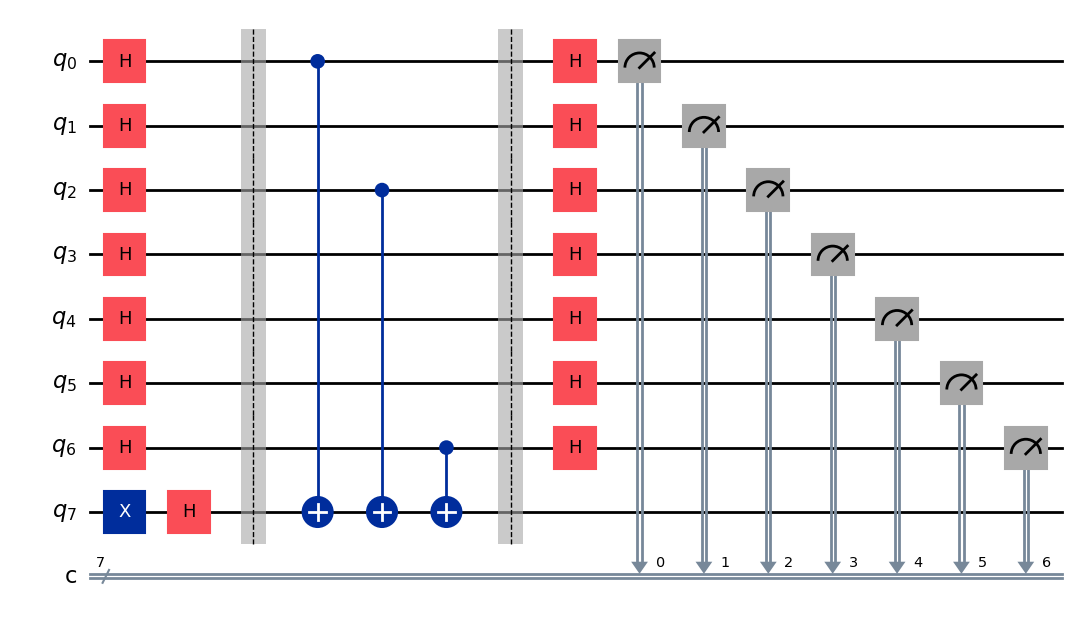

In [8]:
print(f"Gizli Sayı: {secret_number} için devre şeması:")
display(circuit.draw(output='mpl'))

In [9]:
simulator = AerSimulator()
transpiled_circuit = transpile(circuit, simulator)

In [10]:
# Tek bir atış (shot=1) yeterlidir çünkü deterministiktir
result = simulator.run(transpiled_circuit, shots=1).result()
counts = result.get_counts()


Bulunan Sonuç: {'1000101': 1}


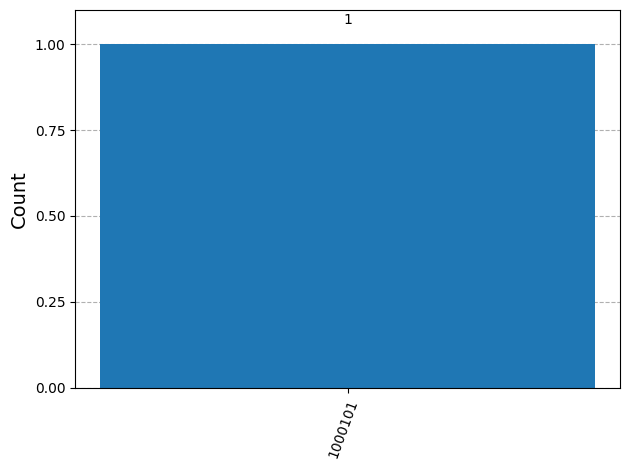

In [11]:
print("\nBulunan Sonuç:", counts)
# Sonucun grafiğini çiz
display(plot_histogram(counts))